<a href="https://colab.research.google.com/github/yayme/skip_attention/blob/master/benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Mar  9 08:55:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import files
uploaded = files.upload()

In [4]:
!rm -rf build/ sparse_attention*.so
!python setup.py build_ext --inplace


running build_ext
W0309 08:56:22.154000 23570 torch/utils/cpp_extension.py:659] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0309 08:56:22.202000 23570 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
building 'sparse_attention' extension
creating build/temp.linux-x86_64-cpython-312
/usr/local/cuda/bin/nvcc -I/usr/local/lib/python3.12/dist-packages/torch/include -I/usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -I/usr/local/cuda/include -I/usr/include/python3.12 -c sparse_attention.cu -o build/temp.linux-x86_64-cpython-312/sparse_attention.o -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr --compiler-options '-fPIC' -DTORCH_API_INCLUDE_EXTENSION_H -DTORCH_EXTENSION_NAME=sparse_attention -gencode=arch=compute

In [5]:

import torch
import sparse_attention as sa
print("extension loaded working")

extension loaded working


In [6]:
N, D = 64,64
Q = torch.randn(N,D, device = 'cuda')
K = torch.randn( N, D, device = 'cuda')
V = torch.randn (N, D, device = 'cuda')
mask = torch.zeros (N,N, dtype = torch.int32)
window, stride = 2,4
for i in range(N):
  for j in range(N):
    local = abs(i-j) <=window
    global_ = (j%stride==0)
    mask[i,j] = 1 if (local or global_) else 0
mask = mask.cuda()

O = sa.sparse_attention(Q,K,V,mask)
print("output shape", O.shape)
print("O[O][:5]", O[0][:5])
print("any Nan?", O.isnan().any().item())

output shape torch.Size([64, 64])
O[O][:5] tensor([ 0.2671, -0.0201,  0.2294, -0.2970, -0.1914], device='cuda:0')
any Nan? False


In [7]:
import torch.nn.functional as F
import math

def pytorch_attention(Q, K, V):
    scale = math.sqrt(Q.size(-1))
    scores = (Q @ K.T) / scale
    weights = F.softmax(scores, dim=-1)
    return weights @ V

O_ref = pytorch_attention(Q, K, V)
print("Reference shape:", O_ref.shape)

Reference shape: torch.Size([64, 64])


In [8]:
import time

def benchmark(fn, runs=100, warmup=10):
    # warmup
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(runs):
        fn()
    torch.cuda.synchronize()
    end = time.perf_counter()

    return (end - start) / runs * 1000  # ms

sparse_ms = benchmark(lambda: sa.sparse_attention(Q, K, V, mask))
dense_ms  = benchmark(lambda: pytorch_attention(Q, K, V))

print(f"Sparse attention: {sparse_ms:.3f} ms")
print(f"Dense  attention: {dense_ms:.3f} ms")
print(f"Speedup: {dense_ms/sparse_ms:.2f}x")

Sparse attention: 1.026 ms
Dense  attention: 0.070 ms
Speedup: 0.07x


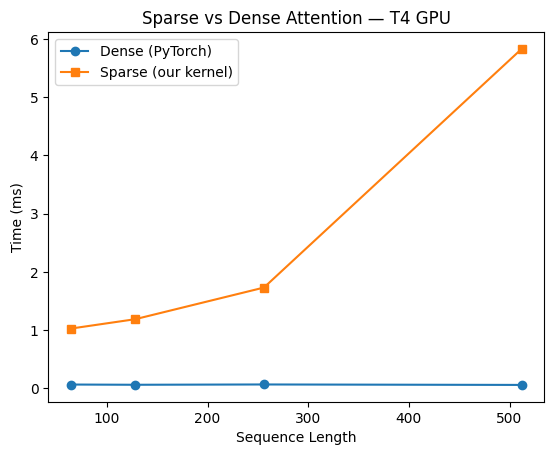

In [9]:
import matplotlib.pyplot as plt

seq_lens = [64, 128, 256, 512]
sparse_times = []
dense_times  = []

for N in seq_lens:
    Q = torch.randn(N, 64, device='cuda')
    K = torch.randn(N, 64, device='cuda')
    V = torch.randn(N, 64, device='cuda')

    mask = torch.zeros(N, N, dtype=torch.int32)
    for i in range(N):
        for j in range(N):
            mask[i,j] = 1 if (abs(i-j) <= 2 or j % 4 == 0) else 0
    mask = mask.cuda()

    sparse_times.append(benchmark(lambda: sa.sparse_attention(Q, K, V, mask)))
    dense_times.append(benchmark(lambda: pytorch_attention(Q, K, V)))

plt.plot(seq_lens, dense_times,  'o-', label='Dense (PyTorch)')
plt.plot(seq_lens, sparse_times, 's-', label='Sparse (our kernel)')
plt.xlabel('Sequence Length')
plt.ylabel('Time (ms)')
plt.title('Sparse vs Dense Attention — T4 GPU')
plt.legend()
plt.savefig('benchmark.png')
plt.show()

In [10]:
import sparse_attention as sa
print(dir(sa))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'sparse_attention', 'sparse_attention_v2']


N=  64 | dense=0.058ms | v1=1.026ms | v2=0.717ms
N= 128 | dense=0.057ms | v1=0.794ms | v2=0.547ms
N= 256 | dense=0.113ms | v1=1.638ms | v2=0.894ms
N= 512 | dense=0.088ms | v1=5.145ms | v2=3.371ms


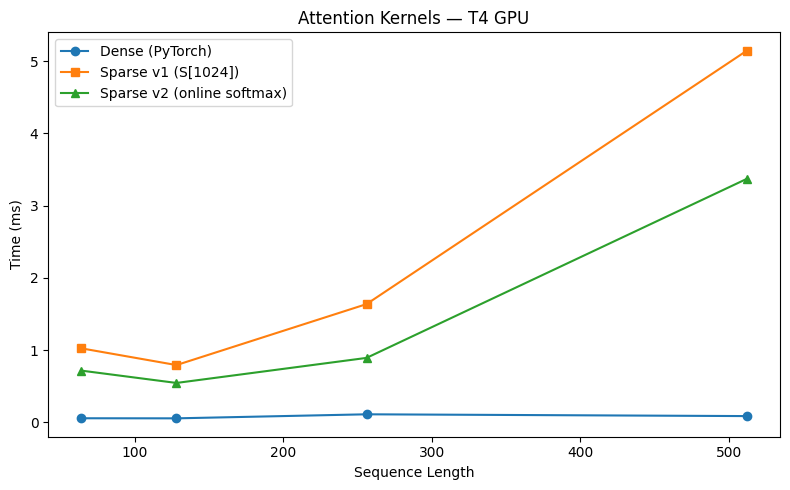


── Speedup of v2 over v1 ──
N=  64: 1.43x
N= 128: 1.45x
N= 256: 1.83x
N= 512: 1.53x


In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
import sparse_attention as sa

# ── helpers ──────────────────────────────────────────
def build_mask(N, window, stride):
    mask = torch.zeros(N, N, dtype=torch.int32)
    for i in range(N):
        for j in range(N):
            if abs(i-j) <= window or j % stride == 0:
                mask[i, j] = 1
    return mask.cuda()

def pytorch_attention(Q, K, V):
    scale = math.sqrt(Q.size(-1))
    scores = (Q @ K.T) / scale
    weights = F.softmax(scores, dim=-1)
    return weights @ V

def benchmark(fn, runs=100, warmup=10):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(runs):
        fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - start) / runs * 1000  # ms

# ── benchmark ─────────────────────────────────────────
seq_lens = [64, 128, 256, 512]
window, stride = 2, 4

v1_times    = []
v2_times    = []
dense_times = []

for N in seq_lens:
    Q    = torch.randn(N, 64, device='cuda')
    K    = torch.randn(N, 64, device='cuda')
    V    = torch.randn(N, 64, device='cuda')
    mask = build_mask(N, window, stride)

    v1_times.append(   benchmark(lambda: sa.sparse_attention(Q, K, V, mask)))
    v2_times.append(   benchmark(lambda: sa.sparse_attention_v2(Q, K, V, mask)))
    dense_times.append(benchmark(lambda: pytorch_attention(Q, K, V)))

    print(f"N={N:4d} | dense={dense_times[-1]:.3f}ms | "
          f"v1={v1_times[-1]:.3f}ms | v2={v2_times[-1]:.3f}ms")

# ── plot ──────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(seq_lens, dense_times, 'o-', label='Dense (PyTorch)')
plt.plot(seq_lens, v1_times,    's-', label='Sparse v1 (S[1024])')
plt.plot(seq_lens, v2_times,    '^-', label='Sparse v2 (online softmax)')
plt.xlabel('Sequence Length')
plt.ylabel('Time (ms)')
plt.title('Attention Kernels — T4 GPU')
plt.legend()
plt.tight_layout()
plt.savefig('benchmark.png', dpi=150)
plt.show()

# ── summary ───────────────────────────────────────────
print("\n── Speedup of v2 over v1 ──")
for i, N in enumerate(seq_lens):
    print(f"N={N:4d}: {v1_times[i]/v2_times[i]:.2f}x")